# Match labelled rows with LLM-extracted rows
1. Load data
2. Vectorize rows
3. Match rows 
4. Compute accuracy


In [1]:
import datetime as dt
import geopandas as gpd
from matplotlib import pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.impact_def import *
from src.accuracy import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load data

In [2]:
#load data (model)
model = "meta-llama_llama-4-scout-17b-16e-instruct"
#"llama-3.1-8b-instant"
# #"llama-3.3-70b-versatile"
# #"meta-llama_llama-4-scout-17b-16e-instruct"
res_savename_ext = f"post_processed_flags_labelled_reports_{model}_v230925"
#f"post_processed_flags_labelled_reports_{model}_v230925"
#"post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_v050925_21rep_meta-llama_llama-4-scout-17b-16e-instruct"
#"post_processed_labelled_reports_test_date_meta-llama_llama-4-scout-17b-16e-instruct_v180925"
extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_flags_labelled_reports_impacts_all_v240925"
#"post_processed_flags_labelled_reports_impacts_all_v240925"
# "post_processed_labelled_reports_impacts_all_v080925"
labelled_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 ="_v011025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+suffix2+".gpkg"))#(res_savename_ext+suffix+suffix2+".gpkg")
suffix2 ="_v011025"
#load data (labelled)
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+suffix2+".gpkg"))#(res_savename_lab+suffix+suffix2+".gpkg")

In [3]:
#reformat output
num_cols = ["impactValue","startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)

##for matching, need to replace NaNs in dates and units as np.nan cannot be compared
labelled_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]] = labelled_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]].fillna(-1)
extracted_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]] = extracted_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]].fillna(-1)
labelled_df["impactUnit"] = labelled_df["impactUnit"].fillna("null")
extracted_df["impactUnit"] =extracted_df["impactUnit"].fillna("null")

DEF_CRS_EPSG = "EPSG:4326"
labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
combined_df = pd.concat([labelled_df, extracted_df])


## Match
1. Vectorize columns that need to be compared using cosine similarity
2. Compute cosine similarity for those columns for each possible extracted-labelled pair
3. Add absolute difference of impactValue between each possible extracted-labelled pair.
    Need to consider NaN from not NaN separately. Only try matching non-NaNs with non-NaNs 
    (and nans with nan?)
4. Compute Intersection-Over-Union of polygons for each possible pair
5. Match by maximizing similarity and -impactvalu_idff and -IoT. Allow for more than one match.  

TO DO:
- Decide if not nan can be matched with nan and vice versa or not

In [4]:
labelled_df = labelled_df[labelled_df["appealCode"] == "MDRHU005"]
extracted_df = extracted_df[extracted_df["appealCode"] == "MDRHU005"]

In [5]:
# weights for matching
weight_set = dict()
weight_set["ws1"] = {#only impsubtype and unit
    'hazards' : 0,
    'country' : 0,
    'startYear' : 0,
    'startMonth' : 0,
    'startDay' : 0,
    'endYear' : 0,
    'endMonth' : 0,
    'endDay' : 0,
    'impactSubtype' : 1,
    'impactUnit' : 1,
    'geometry' : 0, #weight for geometry matching
    'impactValue' : 0
    }
weight_set["ws2"] = {#biased towards impsubtype and impunit
    'hazards' : 1,
    'country' : 2,
    'startYear' : 2,
    'startMonth' : 1,
    'startDay' : 1,
    'endYear' : 1,
    'endMonth' : 1,
    'endDay' : 1,
    'impactSubtype' : 14, #bigger than sum of all other weights (12)
    'impactUnit' : 14,
    'geometry' : 2, #weight for geometry matching
    'impactValue' : 1
    }

weight_set["ws3"] = {#flat
    'hazards' : 1,
    'country' : 1,
    'startYear' : 1,
    'startMonth' : 1,
    'startDay' : 1,
    'endYear' : 1,
    'endMonth' : 1,
    'endDay' : 1,
    'impactSubtype' : 1, #bigger than sum of all other weights (12)
    'impactUnit' : 1,
    'geometry' : 1, #weight for geometry matching
    'impactValue' : 1
    }
weight_set["ws4"] = {#only impsubtype
    'hazards' : 0,
    'country' : 0,
    'startYear' : 0,
    'startMonth' : 0,
    'startDay' : 0,
    'endYear' : 0,
    'endMonth' : 0,
    'endDay' : 0,
    'impactSubtype' : 1,
    'impactUnit' : 0,
    'geometry' : 0, #weight for geometry matching
    'impactValue' : 0
    }

In [6]:
#extracted_df.replace({"Access to Transport and Mobility" : "Mobility and Access to Transport",
#                      "Access to transport and Mobility" : "Mobility and Access to Transport",
#                      "Agriculture Infrastructure" : "Agricultural Infrastructure",
#                      "Other Economic and Livelihood Impacts" : "Other Economic Activity & Livelihood Production",
#                      "Informal settlements" : "Informal Settlements"}, inplace=True)
#labelled_df.replace({"Access to Transport and Mobility" : "Mobility and Access to Transport",
#                      "Access to transport and Mobility" : "Mobility and Access to Transport",
#                      "Agriculture Infrastructure" : "Agricultural Infrastructure",
#                      "Other Economic and Livelihood Impacts" : "Other Economic Activity & Livelihood Production",
#                      "Informal settlements" : "Informal Settlements"}, inplace=True)
#labelled_df = extracted_df


In [7]:
## Parameters
geo_match = True
value_match_pre = False #minimize diff of impactValue simultaneously as cat columns
value_match_post = True #minimize diff of impactValue after matching of cat columns
impactValue_error_clip = None
loose_nan_policy = False #allow NaNs from one side to be matched with all rows from the other side

unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]
unique_country_names = [country.name for country in pycountry.countries]
pattern = '|'.join(map(re.escape, unique_country_names))

unique_dict = {#mapping dictonary of unique values to generate vectors for cosine similarity
    'hazards' : list(hazard_main_types_emdat_desc.keys()),
    'country' : unique_country_names,
    'startYear' : np.arange(1980, 2026).tolist()+[-1],
    'startMonth' : np.arange(1, 13).tolist()+[-1],
    'startDay' : np.arange(1, 32).tolist()+[-1],
    'endYear' : np.arange(1980, 2026).tolist()+[-1],
    'endMonth' : np.arange(1, 13).tolist()+[-1],
    'endDay' : np.arange(1, 32).tolist()+[-1],
    'impactSubtype' : list(impact_subtypes_desc_dict.keys()),
    'impactUnit' : combined_df.impactUnit.unique().tolist(),
}
ws_key = "ws2"
matching_cols_weights = weight_set[ws_key] # weights for matching
### ! similarity cols and matching cols must be in the same order
similarity_cols = list(unique_dict.keys()) #all cols for which cosine similarity needs to be computed
matching_cols = list(matching_cols_weights.keys()) #cols used for matching
#accuracy_cols = list(unique_dict.keys()) + ["geometry"]

## Saving
save_results = False
sim_name = f"{ws_key}-geo-valuepost"
filename_out = f"matched_data_{sim_name}_{res_savename_ext}"
match_idx = []

##Matching
#updating matching columns and weights according to parameters
if not geo_match:
    matching_cols.remove("geometry")
if not value_match_pre:
    matching_cols.remove("impactValue")
else:
    impactValue_error_clip = (0,1)


for appeal, ext_group in extracted_df.groupby("appealCode"):
    print("Processing appeal", appeal)
    ext_group = ext_group.reset_index(drop=False, names=["orig_index"]) #need to reset index to get indices for numpy arrays
    lab_group = labelled_df[labelled_df["appealCode"] == appeal].reset_index(drop=False, names=["orig_index"])

    if (lab_group.shape[0] == 0) or (ext_group.shape[0] == 0):
        continue

    #vectorize
    ext_vect_df = pd.DataFrame(columns=similarity_cols)
    lab_vect_df = pd.DataFrame(columns=similarity_cols)

    for col in similarity_cols:
        ext_vect_df[col] = ext_group[col].apply(vectorize, unique_values=unique_dict[col])
        lab_vect_df[col] = lab_group[col].apply(vectorize, unique_values=unique_dict[col])

    #initialize
    reid_match_ext_group= np.array([])
    reid_match_lab_group = np.array([])
    accuracy_matrix_group = []

    #split between not nans and nans for impactValue
    not_nan_ext_df, not_nan_lab_df, nan_ext_df, nan_lab_df = split_nans(ext_group, lab_group, "impactValue", loose_nan_policy=loose_nan_policy)
    if len(not_nan_ext_df) and len(not_nan_lab_df):
        ext_vect_df_notna = ext_vect_df.loc[not_nan_ext_df.index]
        lab_vect_df_notna = lab_vect_df.loc[not_nan_lab_df.index]

        reid_match_ext, reid_match_lab, accuracy_matrix = match_rows(not_nan_ext_df, not_nan_lab_df, ext_vect_df_notna, lab_vect_df_notna, matching_cols, similarity_cols,  matching_cols_weights, geo_match=geo_match, value_match_pre=value_match_pre, value_match_post=value_match_post)

        #store results for group
        accuracy_matrix_group.append(accuracy_matrix)
        reid_match_ext_group = np.append(reid_match_ext_group, reid_match_ext)
        reid_match_lab_group = np.append(reid_match_lab_group, reid_match_lab)

    if len(nan_ext_df) and len(nan_lab_df):
        ext_vect_df_na = ext_vect_df.loc[nan_ext_df.index]
        lab_vect_df_na = lab_vect_df.loc[nan_lab_df.index]

        #turn off value match for nans
        reid_match_ext, reid_match_lab, accuracy_matrix = match_rows(nan_ext_df, nan_lab_df, ext_vect_df_na, lab_vect_df_na, matching_cols, similarity_cols, matching_cols_weights,  geo_match=geo_match, value_match_pre=False, value_match_post=False)

        #need to append cols of nan to keep dim consistent if there are no impactValues
        if value_match_pre: #or value_match_post:
            accuracy_matrix = np.append(accuracy_matrix, np.full((accuracy_matrix.shape[0], 1), np.nan), axis=1)

        #store results for group
        accuracy_matrix_group.append(accuracy_matrix)
        reid_match_ext_group = np.append(reid_match_ext_group, reid_match_ext)
        reid_match_lab_group = np.append(reid_match_lab_group, reid_match_lab)

    #write as df
    id_accuracy_array = np.append(np.stack((reid_match_ext_group, reid_match_lab_group),axis=1), np.concatenate(accuracy_matrix_group), axis=1)
    match_idx.append(pd.DataFrame(id_accuracy_array,
                                  columns = ["ext_match_id", "lab_match_id"]+matching_cols+["match"]))

match_idx_df = pd.concat(match_idx)

#join extracted and labelled dataframes
matched_df = pd.concat([extracted_df.loc[match_idx_df["ext_match_id"].values].reset_index(drop=True),
                        labelled_df.loc[match_idx_df["lab_match_id"].values].add_suffix('_matched').reset_index(drop=True),
                        match_idx_df.reset_index(drop=True).add_suffix('_sim')], axis=1)
#overwrite / recompute impactValue sim and error
matched_df["impactValue_error"] = max_value_diff(matched_df["impactValue"].values, matched_df["impactValue_matched"].values)
#matched_df["impactValue_sim"] = calc_value_sim(matched_df["impactValue"].values, matched_df["impactValue_matched"].values)#[np.arange(len(matched_df)), np.arange(len(matched_df))]
if "geometry_sim" not in matched_df.columns:
    matched_df["geometry_sim"] = matched_df.apply(lambda x: IoU(x["geometry"], x["geometry_matched"]), axis=1)

if save_results:
    matched_df = delistify_cols(matched_df)
    matched_df.to_feather(DATA_OUT_PROC / (filename_out + ".feather"))


Processing appeal MDRHU005


In [8]:
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather"))

In [9]:
matched_df[["appealCode", "match_sim", "impactSubtype", "impactSubtype_matched", "impactSubtype_sim", "impactValue", "impactValue_matched", "impactValue_error", "impactUnit","impactUnit_matched", "impactUnit_sim", "location", "location_matched", "geometry_sim", "valueAnnotation", "annotation_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactSubtype_sim,impactValue,impactValue_matched,impactValue_error,impactUnit,impactUnit_matched,impactUnit_sim,location,location_matched,geometry_sim,valueAnnotation,annotation_matched
0,MDRBD022,0.967638,Affected People,Affected People,1.0,2176519.00,2176519.00,0.0,people,people,1.0,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.999197,"['Total number of people affected:2,176,519']","['of affected population 2,176,519 No.', 'Six ..."
1,MDRBD022,1.000000,Displaced People,Displaced People,1.0,31818.00,31818.00,0.0,people,people,1.0,[],"['Kurigram district', 'Gaibandha district', 'L...",1.000000,['No. of people who have moved to safe shelter...,"['of people who have moved to safe shelter 31,..."
2,MDRBD022,1.000000,Residential Buildings,Residential Buildings,1.0,3988.00,3988.00,0.0,homes,homes,1.0,[],"['Kurigram district', 'Gaibandha district', 'L...",1.000000,"['No. of fully damaged house3,988']","['of fully damaged house 3,988 No.', 'Six days..."
3,MDRBD022,0.999960,Residential Buildings,Residential Buildings,1.0,98571.00,98571.00,0.0,homes,homes,1.0,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.999197,"['No. of partially damaged house98,571']","['of partially damaged house 98,571 No.', 'Six..."
4,MDRBD022,0.624960,Agricultural Infrastructure,Crop Production and Forestry,0.0,147.33,147.33,0.0,km**2 of crop production and forestry,km**2 of crop production and forestry,1.0,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.999197,"['Amount of crop land damaged (Hectare)14,733']","['of people who have moved to safe shelter 31,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,MDRZM022,0.473415,Access to Healthcare,Other Economic Activity & Livelihood Production,0.0,NaN,NaN,NaN,nan,nan,1.0,"['Southern Province', 'Central, Eastern, North...","['North-Western province', 'Southern province'...",0.968290,['Some expected impacts are compromised food a...,['Page 1 / 21 DREF Operation Zambia Drought 20...
662,MDRZM022,0.642678,Human Health and Wellbeing,Water Quality and Availability,0.0,NaN,NaN,NaN,nan,nan,1.0,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'...",1.000000,['Cholera outbreak and other waterborne diseas...,['Page 1 / 21 DREF Operation Zambia Drought 20...
663,MDRZM022,0.642678,Human Health and Wellbeing,"Access to Water, Sanitation, and Hygiene",0.0,NaN,NaN,NaN,nan,nan,1.0,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'...",1.000000,['Cholera outbreak and other waterborne diseas...,['Page 1 / 21 DREF Operation Zambia Drought 20...
664,MDRZM022,0.642678,Human Health and Wellbeing,Affected Livestock and Animals,0.0,NaN,NaN,NaN,nan,nan,1.0,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'...",1.000000,['Cholera outbreak and other waterborne diseas...,['Page 1 / 21 DREF Operation Zambia Drought 20...


In [10]:
matched_df[matched_df["appealCode"] == "MDRSV012"][["appealCode", "impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched", "valueAnnotation", "annotation_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched,valueAnnotation,annotation_matched
540,MDRSV012,Affected People,Affected People,7085.0,people,7085.0,people,"['eastern regions', 'San Miguel', 'La Unión de...",['El Salvador'],"['Number of people affected:7,085 (1,417 famil...",['DREF Operation n° MDRSV012 GLIDE: n° TC-2018...
541,MDRSV012,Injured People,Injured People,14.0,people,14.0,people,[],"['Morazn department', 'La Union department', '...",['Injured14'],['Situation analysis Description of the disast...
542,MDRSV012,Human Deaths,Human Deaths,4.0,people,1.0,people,[],"['Morazn department', 'La Union department', '...",['Dead4'],['Situation analysis Description of the disast...
543,MDRSV012,Homeless People,Displaced People,1090.0,people,1090.0,people,"['San Miguel', 'La Unión', 'Usulután', 'Sonson...","['Morazn department', 'La Union department', '...","['Sheltered1,090']",['Situation analysis Description of the disast...
544,MDRSV012,Residential Buildings,Residential Buildings,1409.0,homes,1409.0,homes,"['the cantons of El Brazo, La Canoa and El Tec...","['Morazn department', 'La Union department', '...","['Flooded homes1,409']",['Situation analysis Description of the disast...
545,MDRSV012,Residential Buildings,Residential Buildings,2.0,homes,2.0,homes,"['the cantons of El Brazo, La Canoa and El Tec...","['Morazn department', 'La Union department', '...",['Destroyed homes2'],['Situation analysis Description of the disast...
546,MDRSV012,Road Infrastructure,Road Infrastructure,24.0,roads,24.0,roads,[],"['Morazn department', 'La Union department', '...",['Affected highways24'],['Situation analysis Description of the disast...
547,MDRSV012,Road Infrastructure,Road Infrastructure,31.0,roads,31.0,roads,[],"['Morazn department', 'La Union department', '...",['Affected rods31'],['Situation analysis Description of the disast...
548,MDRSV012,Other Infrastructural Impacts,Crop Production and Forestry,42.0,crop production and forestry,42.0,crop production and forestry,[],"['Morazn department', 'La Union department', '...",['Fallen trees42'],['Situation analysis Description of the disast...
549,MDRSV012,Other Infrastructural Impacts,Other Transportation Infrastructure,5.0,vehicles,5.0,vehicles,[],"['Morazn department', 'La Union department', '...",['Vehicles directly affected by the event5'],['Situation analysis Description of the disast...


<Axes: ylabel='appealCode'>

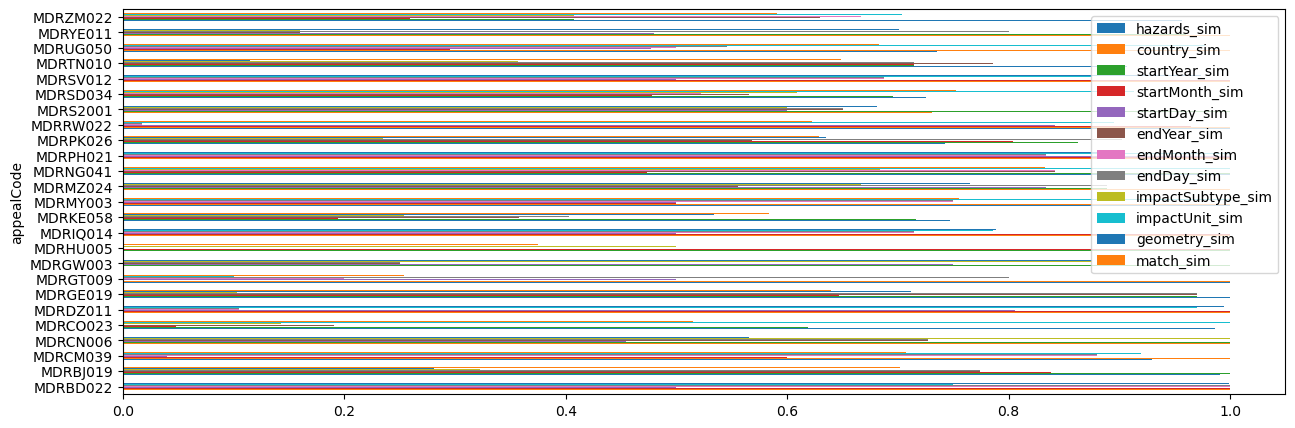

In [11]:
sim_cols = [match_col for match_col in matched_df.columns if "sim" in match_col and match_col not in ["lab_match_id_sim", "ext_match_id_sim"]]
matched_df.groupby("appealCode")[sim_cols].mean().plot(kind="barh", figsize=(15, 5))

<Axes: >

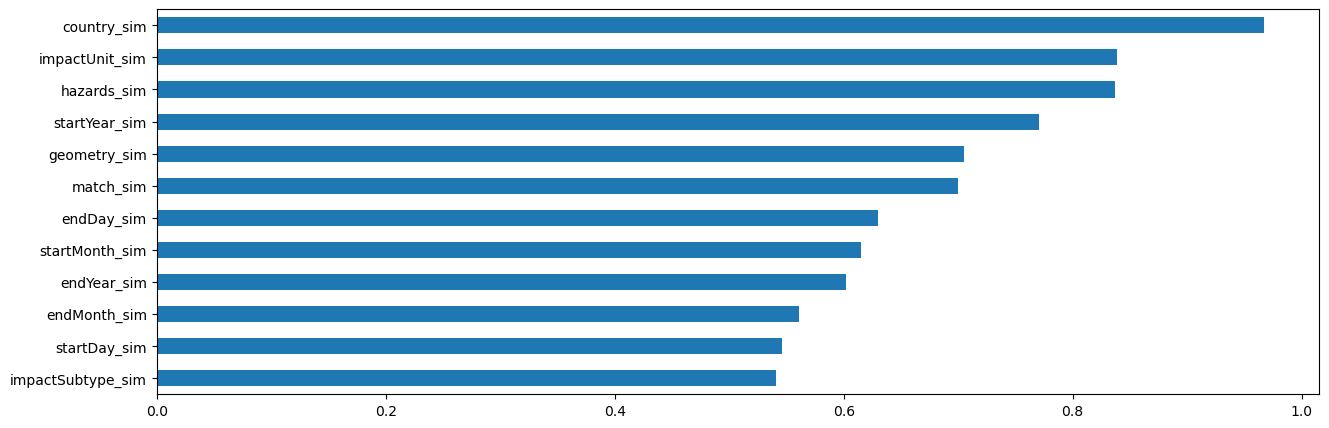

In [12]:
matched_df.groupby("ext_match_id_sim")[sim_cols].mean().mean().sort_values().plot(kind="barh", figsize=(15, 5))

In [13]:
matched_df[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
0,MDRBD022,Affected People,Affected People,2176519.00,people,2176519.00,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
1,MDRBD022,Displaced People,Displaced People,31818.00,people,31818.00,people,[],"['Kurigram district', 'Gaibandha district', 'L..."
2,MDRBD022,Residential Buildings,Residential Buildings,3988.00,homes,3988.00,homes,[],"['Kurigram district', 'Gaibandha district', 'L..."
3,MDRBD022,Residential Buildings,Residential Buildings,98571.00,homes,98571.00,homes,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
4,MDRBD022,Agricultural Infrastructure,Crop Production and Forestry,147.33,km**2 of crop production and forestry,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
...,...,...,...,...,...,...,...,...,...
661,MDRZM022,Access to Healthcare,Other Economic Activity & Livelihood Production,NaN,nan,NaN,nan,"['Southern Province', 'Central, Eastern, North...","['North-Western province', 'Southern province'..."
662,MDRZM022,Human Health and Wellbeing,Water Quality and Availability,NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."
663,MDRZM022,Human Health and Wellbeing,"Access to Water, Sanitation, and Hygiene",NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."
664,MDRZM022,Human Health and Wellbeing,Affected Livestock and Animals,NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."


In [14]:
matched_df[matched_df["impactSubtype"]!= matched_df["impactSubtype_matched"]][["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
4,MDRBD022,Agricultural Infrastructure,Crop Production and Forestry,147.33,km**2 of crop production and forestry,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
6,MDRBD022,Other Infrastructural Impacts,Crop Production and Forestry,690.00,temporary shelters,147.33,km**2 of crop production and forestry,[],"['Kurigram district', 'Gaibandha district', 'L..."
7,MDRBD022,Other Infrastructural Impacts,Crop Production and Forestry,21.00,districts,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
8,MDRBD022,Other Infrastructural Impacts,Crop Production and Forestry,124.00,sub-districts,147.33,km**2 of crop production and forestry,[],"['Kurigram district', 'Gaibandha district', 'L..."
9,MDRBD022,Other Infrastructural Impacts,Crop Production and Forestry,776.00,unions,147.33,km**2 of crop production and forestry,[],"['Kurigram district', 'Gaibandha district', 'L..."
...,...,...,...,...,...,...,...,...,...
661,MDRZM022,Access to Healthcare,Other Economic Activity & Livelihood Production,NaN,nan,NaN,nan,"['Southern Province', 'Central, Eastern, North...","['North-Western province', 'Southern province'..."
662,MDRZM022,Human Health and Wellbeing,Water Quality and Availability,NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."
663,MDRZM022,Human Health and Wellbeing,"Access to Water, Sanitation, and Hygiene",NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."
664,MDRZM022,Human Health and Wellbeing,Affected Livestock and Animals,NaN,nan,NaN,nan,"['Most Districts', 'Zambia']","['North-Western province', 'Southern province'..."


In [15]:
matched_df[matched_df["impactSubtype"]!= matched_df["impactSubtype_matched"]]["impactSubtype"].value_counts()

impactSubtype
Human Health and Wellbeing                         51
Other Human Impacts                                48
Agricultural Infrastructure                        44
Access to Water, Sanitation, and Hygiene           35
Access to Healthcare                               30
Access to Food                                     27
Crop Production and Forestry                       25
Affected Livestock and Animals                     23
Mobility and Access to Transport                   18
Homeless People                                    12
Other Agricultural Impacts                         11
Access to Education                                11
Water Quality and Availability                     10
Other Service Access Impacts                        9
Informal Settlements                                9
Power and Energy Production Infrastructure          9
Other Infrastructural Impacts                       9
Water, Sanitation, and Hygiene Infrastructure       9
IT and Communi

In [16]:
matched_df[matched_df["appealCode"] == "MDRGE019"][["appealCode","match_sim","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
171,MDRGE019,0.584371,Affected People,Access to Power and Energy,28870.0,people,1000.0,people,"['Western Georgia', 'Guria', 'Adjara', 'Imeret...",[]
172,MDRGE019,0.826428,Human Deaths,Human Deaths,3.0,people,1.0,people,"['Guria', 'Western Georgia']",[]
173,MDRGE019,0.900000,Access to Power and Energy,Access to Power and Energy,30000.0,people,30000.0,people,['Imereti'],['Imereti']
174,MDRGE019,0.184371,Residential Buildings,Human Deaths,40.0,homes,1.0,people,"['Western Georgia', 'Guria', 'Adjara', 'Imeret...",[]
175,MDRGE019,0.209371,Road Infrastructure,Human Deaths,42.0,roads,1.0,people,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...",[]
...,...,...,...,...,...,...,...,...,...,...
234,MDRGE019,0.584371,Other Agricultural Impacts,Access to Food,NaN,nan,NaN,nan,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Jumati', 'Konchati', 'Kokati']"
235,MDRGE019,0.584371,Other Agricultural Impacts,Other Service Access Impacts,NaN,nan,NaN,nan,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Jumati', 'Konchati', 'Kokati']"
236,MDRGE019,0.584371,Other Agricultural Impacts,Road Infrastructure,NaN,nan,NaN,nan,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...",[]
237,MDRGE019,0.600000,Power and Energy Production Infrastructure,Mobility and Access to Transport,NaN,nan,NaN,nan,"['Adjara', 'Batumi']",['Adjara']


In [17]:
extracted_df[extracted_df["appealCode"] == "MDRGE019"][["appealCode","impactSubtype", "impactValue", "impactUnit", "location"]]

,appealCode,impactSubtype,impactValue,impactUnit,location
45,MDRGE019,Affected People,28870.0,people,"[Western Georgia, Guria, Adjara, Imereti, Mtsk..."
46,MDRGE019,Human Deaths,3.0,people,"[Guria, Western Georgia]"
47,MDRGE019,Access to Power and Energy,30000.0,people,[Imereti]
48,MDRGE019,Residential Buildings,40.0,homes,"[Western Georgia, Guria, Adjara, Imereti, Mtsk..."
49,MDRGE019,Road Infrastructure,42.0,roads,"[Guria, Adjara, Imereti, Mtskheta-Mtianeti]"
50,MDRGE019,Access to Food,NaN,nan,"[Buknari, Kvenobani, Basileti, Guria, Adjara, ..."
51,MDRGE019,Education Infrastructure,NaN,nan,"[Guria, Adjara, Imereti, Mtskheta-Mtianeti]"
52,MDRGE019,Human Health and Wellbeing,NaN,nan,"[Guria, Adjara, Imereti, Mtskheta-Mtianeti]"
53,MDRGE019,Other Human Impacts,NaN,nan,"[Western Georgia, Guria, Adjara, Imereti, Mtsk..."
54,MDRGE019,"Water, Sanitation, and Hygiene Infrastructure",NaN,nan,"[Guria, Adjara, Imereti, Mtskheta-Mtianeti]"


In [18]:
labelled_df[labelled_df["appealCode"] == "MDRGE019"][["appealCode","impactSubtype", "impactValue", "impactUnit", "location"]]

,appealCode,impactSubtype,impactValue,impactUnit,location
510,MDRGE019,Access to Power and Energy,1000.0,people,[]
511,MDRGE019,Road Infrastructure,NaN,nan,"[Guria, Chokhatauri, Gogole District, Ozurgeti]"
512,MDRGE019,Access to Power and Energy,30000.0,people,[Imereti]
513,MDRGE019,Mobility and Access to Transport,149.0,villages,[]
514,MDRGE019,Other Infrastructural Impacts,20.0,villages,"[Khulo, Shuakhevi, Keda]"
515,MDRGE019,Residential Buildings,NaN,homes,"[Khulo, Shuakhevi, Keda]"
516,MDRGE019,Human Deaths,1.0,people,[]
517,MDRGE019,Residential Buildings,NaN,nan,[]
518,MDRGE019,Education Infrastructure,NaN,nan,[]
519,MDRGE019,Healthcare Infrastructure,NaN,nan,[]


In [19]:
matched_df[matched_df["appealCode"] == "MDRGE019"][sim_cols]

,hazards_sim,country_sim,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,match_sim
171,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.687415,0.584371
172,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.028556,0.826428
173,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.900000
174,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.687415,0.184371
175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.687415,0.209371
...,...,...,...,...,...,...,...,...,...,...,...,...
234,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.687415,0.584371
235,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.687415,0.584371
236,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.687415,0.584371
237,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.000000,0.600000
